# A notebook to train a RANDOM FOREST to perfom a PATCH-based classification (using hand-crafted Features) of kontas_2017 dataset

## Import Usepackages

In [1]:
import torch
import gc

# Force clear everything
torch.cuda.empty_cache()
gc.collect()


import numpy as np
import seaborn as sns
import random
import cv2
import mlflow
import joblib

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, jaccard_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from mpl_toolkits.axes_grid1 import make_axes_locatable

## Pre-defined Functions

In [2]:
def patch_label(mask_patch: np.ndarray) -> int:
    """Return the most frequent class in a 16x16 mask patch."""
    values, counts = np.unique(mask_patch, return_counts=True)
    return int(values[np.argmax(counts)])

In [3]:
def extract_patch_features(patch: np.ndarray) -> np.ndarray:
    """
    Extract meaningful features from a (16, 16, C) image patch.
 
    Feature groups:
        A. Per-band statistics       → mean, std, min, max, skewness, p25, p75
        B. Spectral indices          → NDVI, NDSI, Band ratios (if bands available)
        C. Texture (GLCM)            → contrast, homogeneity, energy, correlation
        D. Spatial gradient (Sobel)  → mean and std of edge magnitude per band
        E. Smoothness                → coefficient of variation (std/mean) per band
 
    Args:
        patch: np.ndarray of shape (16, 16, C), float in [0, 1]
 
    Returns:
        features: 1D np.ndarray
    """
    #H, W = patch.shape[:2]
    #print(H,W)
    features = []

    # Convert to float for calculations
    img_float = patch.astype(np.float32)

    # 1. RGB values (3 features)
    features.append(np.mean(patch[:, :, 0]))  # R
    features.append(np.mean(patch[:, :, 1]))  # G
    features.append(np.mean(patch[:, :, 2]))  # B

    # 2. Color ratios (3 features)
    features.append(np.mean(patch[:, :, 0] / (patch[:, :, 2] + 1e-6)))  # R/B ratio
    features.append(np.mean(patch[:, :, 1] / (patch[:, :, 2] + 1e-6)))  # G/B ratio
    features.append(np.mean((patch[:, :, 0] - patch[:, :, 2]) / (patch[:, :, 0] + patch[:, :, 2] + 1e-6)))  # Normalized R-B


    # 3. HSV color space (3 features)
    hsv = cv2.cvtColor(img_float, cv2.COLOR_RGB2HSV)
    features.append(np.mean(hsv[:, :, 0]))  # Hue
    features.append(np.mean(hsv[:, :, 1]))  # Saturation
    features.append(np.mean(hsv[:, :, 2]))  # Value

    # 4. Local texture features (4 features)
    gray = cv2.cvtColor(img_float, cv2.COLOR_RGB2GRAY)
    # Ensure gray is uint8
    if gray.dtype != np.uint8:
        gray = np.clip(gray, 0, 255).astype(np.uint8)
    features.append(np.mean(cv2.GaussianBlur(gray, (5, 5), 0)))  # Smoothed intensity
    #features.append(cv2.Laplacian(gray, cv2.CV_64F))  # Edge detection
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    features.append(np.mean(laplacian.astype(np.float32)))  # Edge detection
    features.append(np.mean(cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)))  # Gradient X
    features.append(np.mean(cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)))  # Gradient Y

    # 5. Local statistics (3 features)
    kernel_size = 5
    mean_filter = cv2.blur(gray.astype(float), (kernel_size, kernel_size))
    features.append(np.mean(mean_filter))  # Local mean
    
    variance = cv2.blur((gray.astype(float) - mean_filter)**2, (kernel_size, kernel_size))
    features.append(np.mean(variance))  # Local variance
    features.append(np.mean(np.sqrt(variance + 1e-6)))  # Local std


    return np.array(features, dtype=np.float32)
 


In [4]:
def extract_patches_sliding(image, patch_size=32, stride=8):
    """
    image: np.array (H, W, C) or tensor (C, H, W)
    Returns: patches (N, patch_size, patch_size, C), coords (N, 2) top-left (row, col)
    """
    if isinstance(image, torch.Tensor):
        image = image.numpy().transpose(1, 2, 0)  # C,H,W -> H,W,C

    H, W, C = image.shape
    patches, coords = [], []

    for r in range(0, H - patch_size + 1, stride):
        for c in range(0, W - patch_size + 1, stride):
            patch = image[r:r+patch_size, c:c+patch_size]   # (P, P, C)
            patches.append(patch.astype(np.float32))
            coords.append((r, c))

    return np.stack(patches), coords  # (N, P, P, C), list of (r,c)


def predict_mask_sliding(rf, image, patch_size=32, stride=8, n_classes=3):
    """
    rf:    trained RandomForestClassifier
    image: np.array (H, W, C), values in [0, 255] or [0, 1]
    Returns: predicted mask (H, W) with class indices
    """
    H, W = image.shape[:2]

    # vote_map[r, c, class] = number of patches that voted for this class at pixel (r,c)
    vote_map = np.zeros((H, W, n_classes), dtype=np.int32)

    patches, coords = extract_patches_sliding(image, patch_size, stride)

    # Extract hand-crafted features and predict for all patches
    features = np.stack([extract_patch_features(p) for p in patches])  # (N, n_features)
    predictions = rf.predict(features)                                  # (N,) class indices

    # Accumulate votes — every pixel covered by a patch gets one vote
    for (r, c), pred in zip(coords, predictions):
        vote_map[r:r+patch_size, c:c+patch_size, pred] += 1

    # Final label = class with most votes at each pixel
    mask = np.argmax(vote_map, axis=-1)   # (H, W)
    return mask

In [5]:
def show_predicted_images(idxExample,imgExample,masks,pred_mask):

    cmap = ListedColormap(['black', 'blue', 'white'])

    fig, axes = plt.subplots(2, 3, figsize=(7, 5))

    axes[0,0].imshow(imgExample.squeeze())
    axes[0,0].set_title(f'Original Image {idxExample}')
    axes[0,0].axis('off')

    axes[0,1].imshow(masks[idxExample:idxExample+1].squeeze(), cmap=cmap, vmin=0, vmax=2)
    axes[0,1].set_title(f'Original Mask')
    axes[0,1].axis('off')

    axes[0,2].imshow(pred_mask.squeeze(), cmap=cmap, vmin=0, vmax=2)
    axes[0,2].set_title(f'Predicted Mask')
    axes[0,2].axis('off')



    diff = masks[idxExample].squeeze().astype(int) - pred_mask.squeeze().astype(int)

    im  = axes[1,2].imshow(diff, cmap='RdBu', vmin=-2, vmax=2)
    axes[1,2].set_title('Mask Differences')
    axes[1,2].axis('off')


    axes[1,0].axis('off')  # just turn it off — leaves it blank
    axes[1,1].axis('off')  # just turn it off — leaves it blank

    # Attach colorbar to axes[3] without stealing space from other plots
    divider = make_axes_locatable(axes[1,2])
    cax     = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax, ticks=[-2, -1, 0, 1, 2])


    unique, counts = np.unique(diff, return_counts=True)
    total = diff.size

    print(f"{'Value':>8} {'Count':>10} {'Percentage':>12}")
    print("-" * 32)
    for val, cnt in zip(unique, counts):
        print(f"{val:>8} {cnt:>10,} {cnt/total:>11.1%}")


## Load Data

The data were generated with the script: 01_kontas2017_dataPreparation. Therefore, they only have to be loaded here!

In [6]:
# Load in another notebook:
data   = np.load("datasetPatch.npz") #, images_patch=images_patch, masks_patch=masks_patch,all_masks=labs_patch)
images_patch = data["images_patch"].copy()  # force full load
masks_patch  = data["masks_patch"].copy()
labs_patch  = data["all_masks"].copy()
data.close()
del data

data   = np.load("dataset.npz") #np.savez("dataset.npz", images=images, masks=masks)
images = data["images"].copy()  # force full load
masks  = data["masks"].copy()
data.close()
del data



print("Number of images: ",len(images_patch))
print("Number of masks: ",len(masks_patch))
print(f" - Size of an image: {images_patch[0].shape}")
print(" - Size of a mask: ",masks_patch[0].shape)


Number of images:  394240
Number of masks:  394240
 - Size of an image: (32, 32, 3)
 - Size of a mask:  (32, 32)


## Feature Extraction

The function memmap from numpy is used to avoid problems with "Kernel crash".

In [7]:
features_patch = []

for idx in range(images_patch.shape[0]):
    X = extract_patch_features(images_patch[idx])
    features_patch.append(X)

features_patch = np.vstack(features_patch)

## Train the RANDOM FOREST

In [8]:
# Data size check!
print(f"features: {features_patch.shape}")
print(f"labels: {labs_patch.shape}")

features: (394240, 16)
labels: (394240,)


In [9]:
# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    features_patch, labs_patch, test_size=0.3, random_state=42, stratify=labs_patch
)

# Second split: split temp into 50/50 → 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.333333, random_state=42, stratify=y_temp
)

print(f"\nTraining samples: {len(X_train):,}")
print(f"Class distribution: {np.bincount(y_train.astype(int))}")
print(f"Test samples: {len(X_test):,}")
print(f"Class distribution: {np.bincount(y_test.astype(int))}")


Training samples: 275,968
Class distribution: [ 59965 127729  88274]
Test samples: 39,424
Class distribution: [ 8566 18247 12611]


In [10]:
# Define architecture of Random Forest

#The following hyperparameters are used:
#n_est=50, depth=30, maxFeature=sqrt, minSamplesSplit=20, minSampleLeaf=5

# from RandomForest_Pixel_Hand-script
n_est = 50
max_depth = 30
maxF = 'sqrt'
minSample = 20
minSampleLeaf = 5 

rfPatch = RandomForestClassifier(
    n_estimators=n_est,
    max_depth=max_depth,
    min_samples_split=minSample,
    min_samples_leaf=minSampleLeaf,
    max_features=maxF,
    verbose=1,
    n_jobs=-1, random_state=42,
    class_weight='balanced'
    )

In [11]:
rfPatch.fit(X_train, y_train)
print("Training complete!")
print(f"RF train accuracy: {rfPatch.score(X_train, y_train):.3f}")
print(f"RF test accuracy: {rfPatch.score(X_test, y_test):.3f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    4.4s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s


Training complete!
RF train accuracy: 0.960
RF test accuracy: 0.929


[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.2s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      8566
           1       0.93      0.93      0.93     18247
           2       0.89      0.89      0.89     12611

    accuracy                           0.93     39424
   macro avg       0.93      0.94      0.94     39424
weighted avg       0.93      0.93      0.93     39424


Confusion Matrix:
[[ 8437    43    86]
 [   57 16929  1261]
 [   99  1236 11276]]


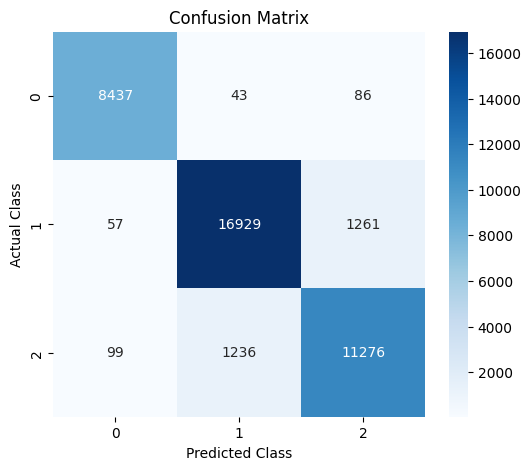

In [12]:
# Predictions
y_pred = rfPatch.predict(X_test)

# Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2],
            yticklabels=[0,1,2])

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.2s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with

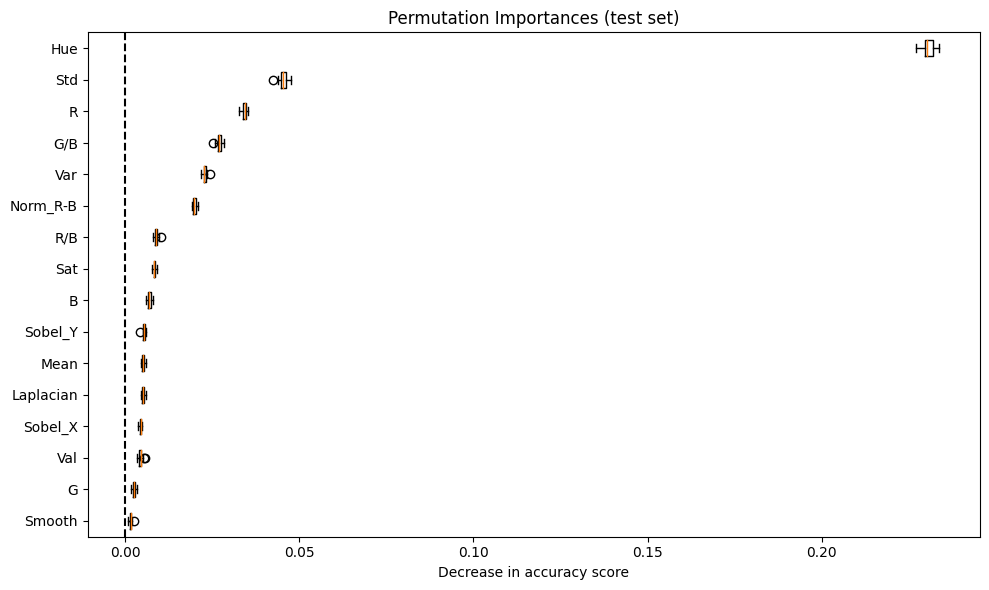

In [13]:
# Permutation Feature importance
feature_names = ['R', 'G', 'B', 'R/B', 'G/B', 'Norm_R-B', 
                 'Hue', 'Sat', 'Val', 'Smooth', 'Laplacian', 
                 'Sobel_X', 'Sobel_Y', 'Mean', 'Var', 'Std']

result = permutation_importance(
    rfPatch, X_test, y_test, n_repeats=20, random_state=42, n_jobs=2
)

sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(result.importances[sorted_idx].T,
           vert=False,
           labels=np.array(feature_names)[sorted_idx])
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
fig.tight_layout()
plt.show()

## Image resp. Mask Reproduction

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


   Value      Count   Percentage
--------------------------------
      -2      2,688        1.0%
      -1     10,658        4.1%
       0    241,518       92.1%
       1      5,192        2.0%
       2      2,088        0.8%


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


   Value      Count   Percentage
--------------------------------
      -2      7,340        2.8%
      -1         45        0.0%
       0    252,806       96.4%
       1      1,216        0.5%
       2        737        0.3%


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


...

   Value      Count   Percentage
--------------------------------
      -2      4,356        1.7%
      -1      6,512        2.5%
       0    234,338       89.4%
       1     14,860        5.7%
       2      2,078        0.8%


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


   Value      Count   Percentage
--------------------------------
      -2      6,198        2.4%
      -1     17,225        6.6%
       0    222,480       84.9%
       1     15,128        5.8%
       2      1,113        0.4%


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


   Value      Count   Percentage
--------------------------------
      -2      3,710        1.4%
      -1     79,814       30.4%
       0    173,492       66.2%
       1      3,934        1.5%
       2      1,194        0.5%


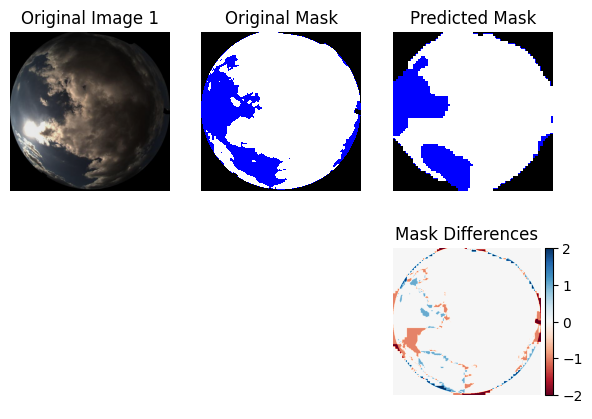

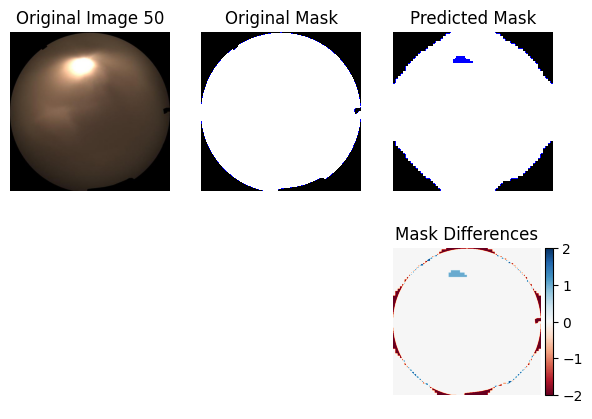

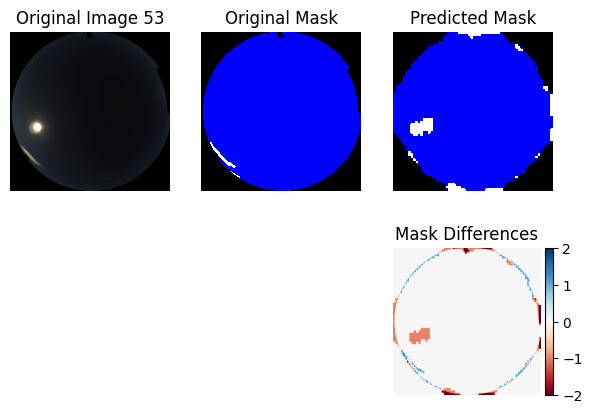

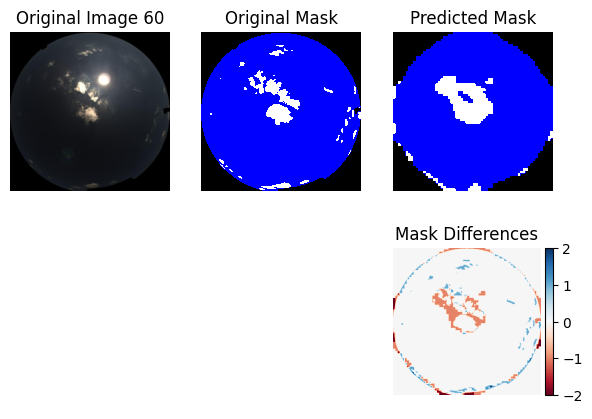

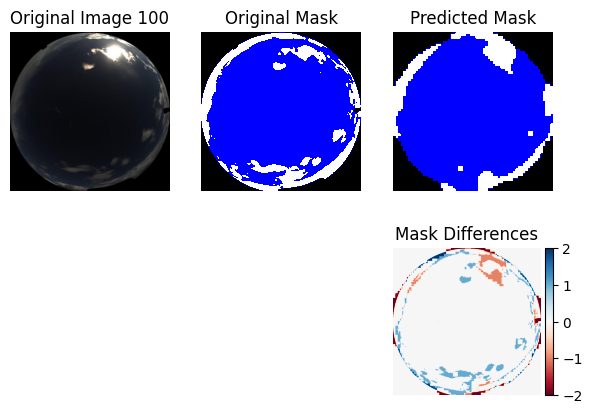

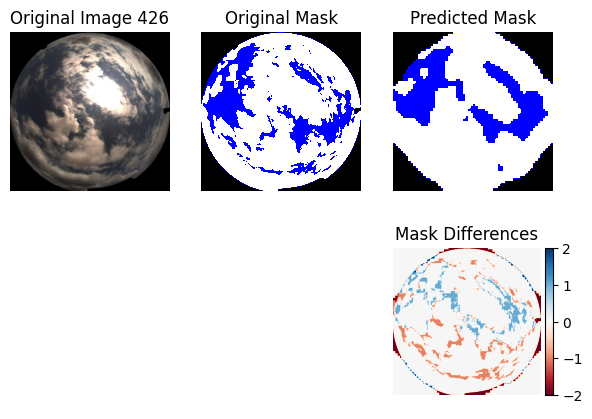

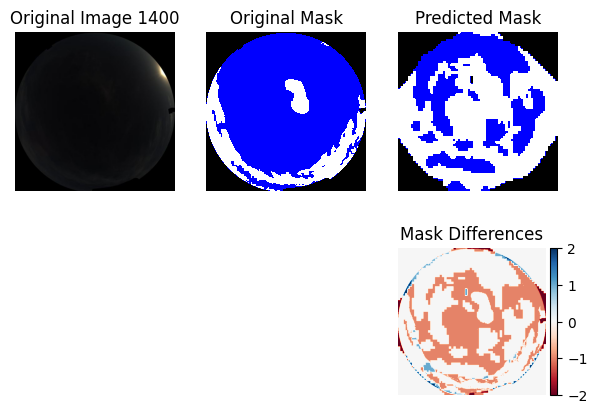

In [14]:
for idxExample in [1,50,53,60,100,426, 1400]:


    imgExample = images[idxExample:idxExample+1].squeeze(0)


    pred_mask = predict_mask_sliding(
        rfPatch, imgExample,
        patch_size=32,
        stride=8,       # smaller = smoother edges, slower
        n_classes=3
    )   

    # Visualize results

    show_predicted_images(idxExample,imgExample,masks,pred_mask)


In [15]:
## Apply Random Forest on SwissOGS Images

In [16]:
# Define image and mask files
basePath = Path(r'SwissOGS')

# Append last_dir
image_path = basePath


image_paths = sorted(Path(image_path).glob("*.jpg"))

In [17]:
# Get data


imagesOGS = []

for idx, img_path in enumerate(image_paths):
    image = Image.open(img_path).convert("RGB")
    image.load()
    imagesOGS.append(image)

# Data set
imagesOGS = [np.array(img) for img in imagesOGS]

print("Number of images: ",len(imagesOGS))

print(" - Size of a image: ",imagesOGS[0].shape)

Number of images:  6
 - Size of a image:  (2822, 3044, 3)


In [24]:
def show_predicted_imagesOGS(idxExample,imgExample,pred_mask):

    cmap = ListedColormap(['black', 'blue', 'white'])

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].imshow(np.array(imgExample))
    axes[0].set_title(f'Original Image {idxExample}')
    axes[0].axis('off')

    axes[1].imshow(pred_mask.squeeze(), cmap=cmap, vmin=0, vmax=2)
    axes[1].set_title(f'Predicted Mask')
    axes[1].axis('off')



<class 'numpy.ndarray'> (2822, 3044, 3)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


<class 'numpy.ndarray'> (2822, 3044, 3)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


<class 'numpy.ndarray'> (2822, 3044, 3)


...

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished


<class 'numpy.ndarray'> (2822, 3044, 3)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


<class 'numpy.ndarray'> (2822, 3044, 3)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


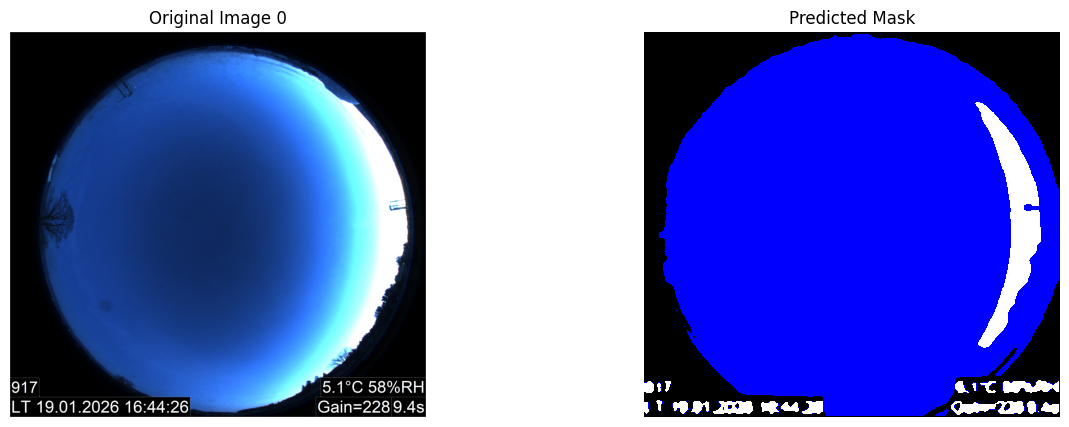

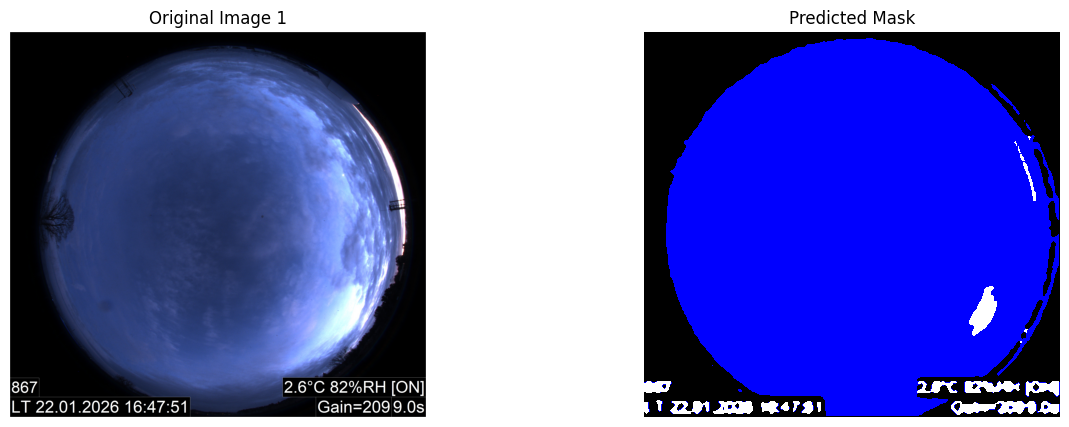

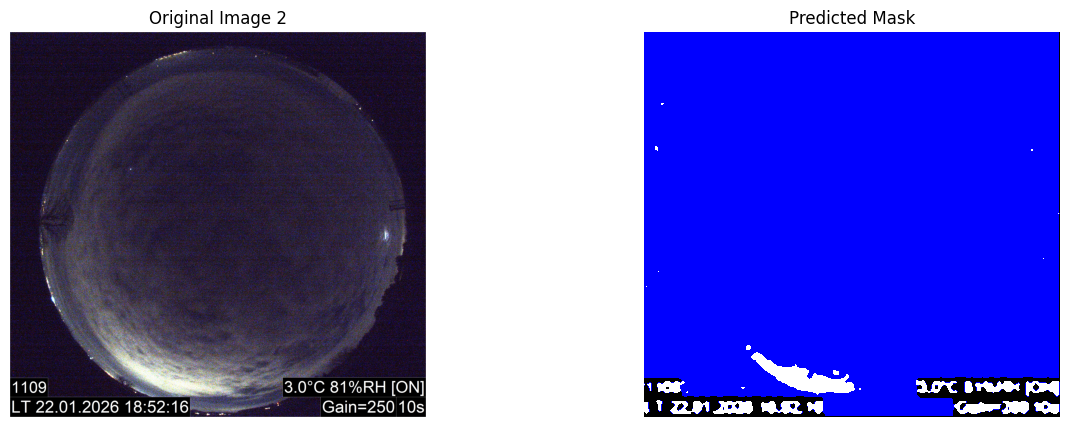

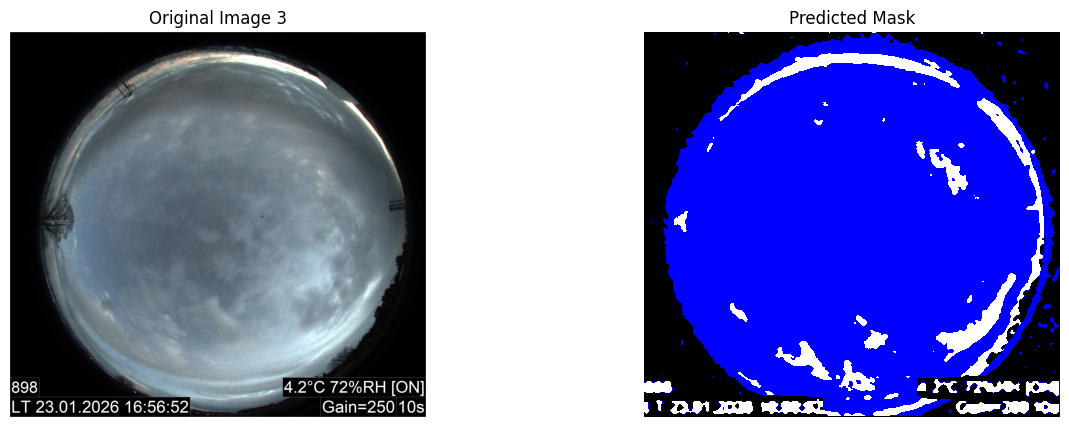

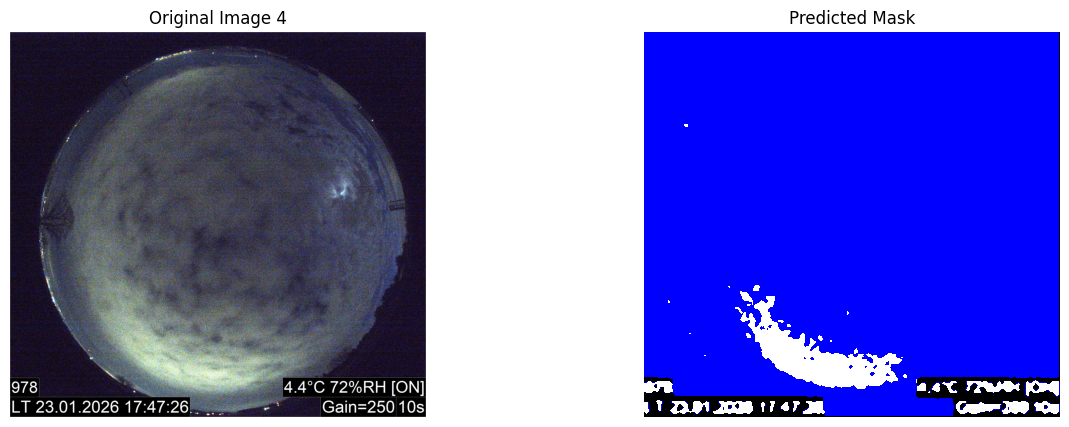

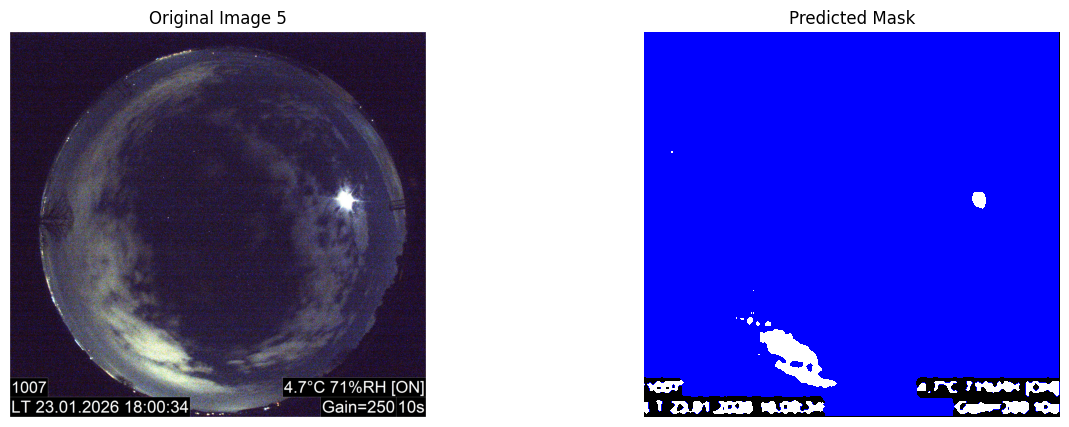

In [25]:
for idxExample in range(len(imagesOGS)):

    imgExample = imagesOGS[idxExample]
    print(type(imagesOGS[idxExample]), imagesOGS[idxExample].shape)


    # Visualize results
    pred_mask = predict_mask_sliding(
        rfPatch, imgExample,
        patch_size=32,
        stride=8,       # smaller = smoother edges, slower
        n_classes=3
    )  

    show_predicted_imagesOGS(idxExample,imgExample,pred_mask)

## Save the Model

In [ ]:
import joblib

# Save trained model
joblib.dump(rfPatch, 'cloud_detection_rfPatch.pkl')
print("Model saved!")

# Load model later with:
# rf_loaded = joblib.load('cloud_detection_rf.pkl')

Model saved!
